Neuronal net with cylinical split data

In [18]:
# ============================================================
# 0) Imports
# ============================================================
%pip -q install tensorflow scikit-learn joblib

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
import joblib

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
# ============================================================
# 1) Load your pre-split data
# ============================================================
TRAIN_PATH = "/workspaces/bakery_prediction/0_DataPreparation/Split_data/03_cylindical/train_data.csv"
VAL_PATH   = "/workspaces/bakery_prediction/0_DataPreparation/Split_data/03_cylindical/val_data.csv"
TEST_PATH  = "/workspaces/bakery_prediction/0_DataPreparation/Split_data/03_cylindical/test_data.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# if you have a date column, parse it (optional for the NN, useful for checks)
if "Datum" in train_df.columns:
    train_df["Datum"] = pd.to_datetime(train_df["Datum"])
    val_df["Datum"]   = pd.to_datetime(val_df["Datum"])
    test_df["Datum"]  = pd.to_datetime(test_df["Datum"])

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(7493, 23) (1841, 23) (1830, 23)


,id,Datum,Warengruppe,Umsatz,KielerWoche,Bewoelkung,Temperatur,Windgeschwindigkeit,Woche,Monat,...,Ferien,sunny,cloudy,rainy,thunderstorm,is_weekend,sin_Monat,cos_Monat,sin_Wochentag,cos_Wochentag
0,1307011,2013-07-01,1,148.828353,0,6,17.8375,15,27,7,...,0,0,1,0,0,0,-0.5,-0.866025,0.781831,0.62349
1,1307012,2013-07-01,2,535.856285,0,6,17.8375,15,27,7,...,0,0,1,0,0,0,-0.5,-0.866025,0.781831,0.62349
2,1307013,2013-07-01,3,201.198426,0,6,17.8375,15,27,7,...,0,0,1,0,0,0,-0.5,-0.866025,0.781831,0.62349
3,1307014,2013-07-01,4,65.890169,0,6,17.8375,15,27,7,...,0,0,1,0,0,0,-0.5,-0.866025,0.781831,0.62349
4,1307015,2013-07-01,5,317.475875,0,6,17.8375,15,27,7,...,0,0,1,0,0,0,-0.5,-0.866025,0.781831,0.62349


In [20]:
# ============================================================
# 2) Define target + feature columns
#    (adjust drop list to your columns)
# ============================================================
TARGET_COL = "Umsatz"

drop_cols = []
for c in ["id", "Datum"]:
    if c in train_df.columns:
        drop_cols.append(c)

# IMPORTANT: avoid leakage for forecasting:
# if Umsatz_roll is computed using future values, drop it.
# If it's computed only from past values at that date, it can stay.
if "Umsatz_roll" in train_df.columns:
    drop_cols.append("Umsatz_roll")

feature_cols = [c for c in train_df.columns if c not in drop_cols + [TARGET_COL]]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()

X_val   = val_df[feature_cols].copy()
y_val   = val_df[TARGET_COL].copy()

X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET_COL].copy()

print("n_features:", len(feature_cols))


n_features: 20


In [21]:
# ============================================================
# 3) Scale features (fit ONLY on train)
# ============================================================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

os.makedirs("3_Model/class file/pickle_data", exist_ok=True)
joblib.dump(scaler, "3_Model/class file/pickle_data/scaler.joblib")
pd.to_pickle(feature_cols, "3_Model/class file/pickle_data/feature_cols.pkl")


In [23]:
# ============================================================
# 4) Build + train neural net
# ============================================================
tf.random.set_seed(42)

model = Sequential([
    InputLayer(shape=(X_train_s.shape[1],)),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=Adam(1e-3),
    loss="mape",
    metrics=["mape"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6),
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

model.save("3_Model/class file/python_model.keras")


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 96.4105 - mape: 96.4105 - val_loss: 97.4990 - val_mape: 97.4990 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87.7636 - mape: 87.7636 - val_loss: 88.6566 - val_mape: 88.6566 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 72.9948 - mape: 72.9948 - val_loss: 72.9595 - val_mape: 72.9595 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 56.8352 - mape: 56.8352 - val_loss: 59.1796 - val_mape: 59.1796 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 49.3139 - mape: 49.3139 - val_loss: 55.3504 - val_mape: 55.3504 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 47.9489 - mape: 47.9489 - val_loss: 54.7113 - val_mape: 54.7113 - learning_rate: 0.0010
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 47.3815 - mape: 47.3815 - val_loss: 52.7594 - val_mape: 52

In [ ]:
#load model
model = tf.keras.models.load_model(r"/workspaces/bakery_prediction/3_Model/01_ls_neuronal_net_model/3_Model/class file/python_model.keras")

2026-01-06 15:43:35.619136: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


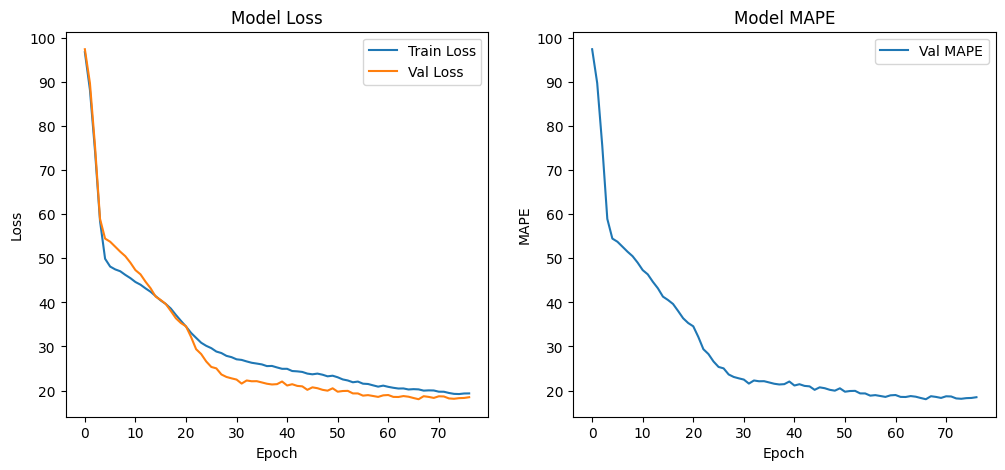

In [ ]:
#plot training history
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['val_mape'], label='Val MAPE')
plt.title('Model MAPE')
plt.xlabel('Epoch')
plt.ylabel('MAPE')
plt.legend()
plt.show()

In [ ]:
def mape_safe(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100



In [35]:
# ============================================================
# 5) Evaluate overall + per Warengruppe (VAL + TEST)
# ============================================================
def mape(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ---- VAL: usar dados escalados e ignorar NaNs no alvo
mask_val = ~y_val.isna()
y_val_clean = y_val[mask_val].to_numpy()
val_pred = model.predict(X_val_s[mask_val.to_numpy()], verbose=0).reshape(-1)

print("VAL  MAE :", np.mean(np.abs(y_val_clean - val_pred)))
print("VAL  MAPE:", mape_safe(y_val_clean, val_pred))
print("VAL  R²  :", 1 - np.sum((y_val_clean - val_pred) ** 2) / np.sum((y_val_clean - np.mean(y_val_clean)) ** 2))

# ---- TEST: usar dados escalados e ignorar NaNs no alvo
mask_test = ~y_test.isna()
if mask_test.sum() == 0:
    print("TEST: nenhum y válido após remover NaNs; pulando métricas.")
else:
    y_test_clean = y_test[mask_test].to_numpy()
    test_pred = model.predict(X_test_s[mask_test.to_numpy()], verbose=0).reshape(-1)
    print("TEST MAE :", np.mean(np.abs(y_test_clean - test_pred)))
    print("TEST MAPE:", mape_safe(y_test_clean, test_pred))
    print("TEST R²  :", 1 - np.sum((y_test_clean - test_pred) ** 2) / np.sum((y_test_clean - np.mean(y_test_clean)) ** 2))


VAL  MAE : 31.92873695925383
VAL  MAPE: 18.139562929968033
VAL  R²  : 0.8305990033448667
TEST: nenhum y válido após remover NaNs; pulando métricas.


In [39]:
# ============================================================
# 5) Evaluate overall + per Warengruppe (VAL + TEST)
# ============================================================

def get_warengruppe_series(df):
    if "Warengruppe" in df.columns:
        return df["Warengruppe"].astype(int)
    wg_cols = [c for c in df.columns if c.startswith("Warengruppe_")]
    prefix = "Warengruppe_"
    if not wg_cols:
        wg_cols = [c for c in df.columns if c.startswith("Group_")]
        prefix = "Group_"
    if not wg_cols:
        raise ValueError("Warengruppe not found neither as a column nor as one-hot (Warengruppe_*/Group_*).")
    return df[wg_cols].idxmax(axis=1).str.replace(prefix, "", regex=False).astype(int)

# ---- predictions with NaN-safe masks
mask_val = ~y_val.isna()
y_val_clean = y_val[mask_val].to_numpy()
val_pred = model.predict(X_val_s[mask_val.to_numpy()], verbose=0).reshape(-1)

mask_test = ~y_test.isna()
test_pred = None
if mask_test.any():
    y_test_clean = y_test[mask_test].to_numpy()
    test_pred = model.predict(X_test_s[mask_test.to_numpy()], verbose=0).reshape(-1)

# ---- overall metrics
print("VAL  MAE :", np.mean(np.abs(y_val_clean - val_pred)))
print("VAL  MAPE:", mape_safe(y_val_clean, val_pred))

if mask_test.any():
    print("TEST MAE :", np.mean(np.abs(y_test_clean - test_pred)))
    print("TEST MAPE:", mape_safe(y_test_clean, test_pred))
else:
    print("TEST metrics: skipped (all NaNs in y_test)")

# ---- per Warengruppe on VAL (using only valid rows)
df_val_eval = val_df.loc[mask_val].copy()
df_val_eval["Warengruppe"] = get_warengruppe_series(df_val_eval)
df_val_eval["y_true"] = y_val_clean
df_val_eval["y_pred"] = val_pred

mape_by_group_val = (
    df_val_eval.groupby("Warengruppe")
    .apply(lambda g: mape_safe(g["y_true"], g["y_pred"]))
    .reset_index(name="MAPE")
    .sort_values("Warengruppe")
)

print("\nMAPE by Warengruppe (VAL):")
print(mape_by_group_val.to_string(index=False))
print("\nMacro-MAPE (VAL):", mape_by_group_val["MAPE"].mean())
print("Micro-MAPE (VAL):", mape_safe(df_val_eval["y_true"], df_val_eval["y_pred"]))


VAL  MAE : 31.92873695925383
VAL  MAPE: 18.139562929968033
TEST metrics: skipped (all NaNs in y_test)

MAPE by Warengruppe (VAL):
 Warengruppe      MAPE
           1 19.058673
           2 12.424456
           3 17.984806
           4 22.388828
           5 15.028076
           6 42.447279

Macro-MAPE (VAL): 21.555353116423134
Micro-MAPE (VAL): 18.139562929968033


/tmp/ipykernel_16209/3291281828.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mape_safe(g["y_true"], g["y_pred"]))


In [ ]:
# X_test_s já escalado com scaler do train
test_pred = model.predict(X_test_s, verbose=0).reshape(-1)

test_out = test_df.copy()
test_out["Umsatz_pred"] = test_pred
test_out.to_csv("3_Model/nn_submission_2.csv", index=False)
print("Saved: 3_Model/nn_submission_2.csv")

Saved: 3_Model/test_predictions.csv
